# Insight 4: tipo de cliente y tamano familiar

La exploracion previa encontro una asociacion perfecta entre tipo de cliente y tamano familiar (V de Cramer = 1 en el calculo inicial). Es un patron llamativo que conviene verificar: el notebook muestra la tabla completa y recalcula la medida con correccion de sesgo. No debe interpretarse como evidencia de que el tamano familiar cause la frecuencia de compra.

In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

ruta_dataset = Path('..') / 'data' / 'online food delivery dataset.csv'
df = pd.read_csv(ruta_dataset)
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
df = df.apply(
    lambda columna: columna.str.strip()
    if pd.api.types.is_string_dtype(columna.dtype)
    else columna
)

tabla = pd.crosstab(df['Customer Type'], df['Family size'])
porcentajes = pd.crosstab(df['Customer Type'], df['Family size'], normalize='index').mul(100)
display(tabla)
display(porcentajes.round(1))

Family size,1,2,3,4,5,6
Customer Type,,,,,,
Frequent,0,0,0,63,54,29
New,24,0,0,0,0,0
Regular,0,101,117,0,0,0


Family size,1,2,3,4,5,6
Customer Type,,,,,,
Frequent,0.0,0.0,0.0,43.2,37.0,19.9
New,100.0,0.0,0.0,0.0,0.0,0.0
Regular,0.0,46.3,53.7,0.0,0.0,0.0


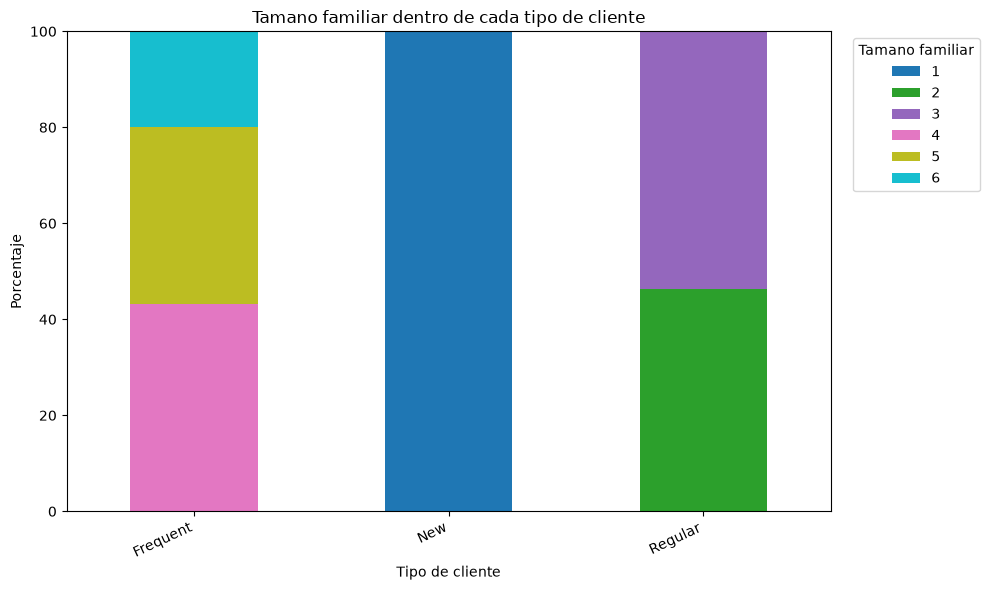

In [5]:
ax = porcentajes.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab10')
ax.set_title('Tamano familiar dentro de cada tipo de cliente')
ax.set_xlabel('Tipo de cliente')
ax.set_ylabel('Porcentaje')
ax.legend(title='Tamano familiar', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

In [6]:
chi2, p_valor, grados_libertad, esperadas = chi2_contingency(tabla)
n = tabla.to_numpy().sum()
filas, columnas = tabla.shape
phi2 = chi2 / n
phi2_corregido = max(0, phi2 - ((columnas - 1) * (filas - 1)) / (n - 1))
filas_corregidas = filas - ((filas - 1) ** 2) / (n - 1)
columnas_corregidas = columnas - ((columnas - 1) ** 2) / (n - 1)
v_cramer = (phi2_corregido / max(1, min(columnas_corregidas - 1, filas_corregidas - 1))) ** 0.5
print(f'Chi-cuadrado: {chi2:.3f} | gl: {grados_libertad} | p-valor: {p_valor:.6g}')
print(f"V de Cramer (corregida): {v_cramer:.3f}")
print('Verifica celdas con frecuencias bajas antes de generalizar este resultado.')

Chi-cuadrado: 776.000 | gl: 10 | p-valor: 2.97403e-160
V de Cramer (corregida): 0.996
Verifica celdas con frecuencias bajas antes de generalizar este resultado.


,variable,tipo_analitico,dtype_pandas,categorias_observadas
0,Customer Type,Categórica ordinal,str,"[Frequent, New, Regular]"
1,Family size,Cuantitativa discreta (conteo),int64,"[1, 2, 3, 4, 5, 6]"


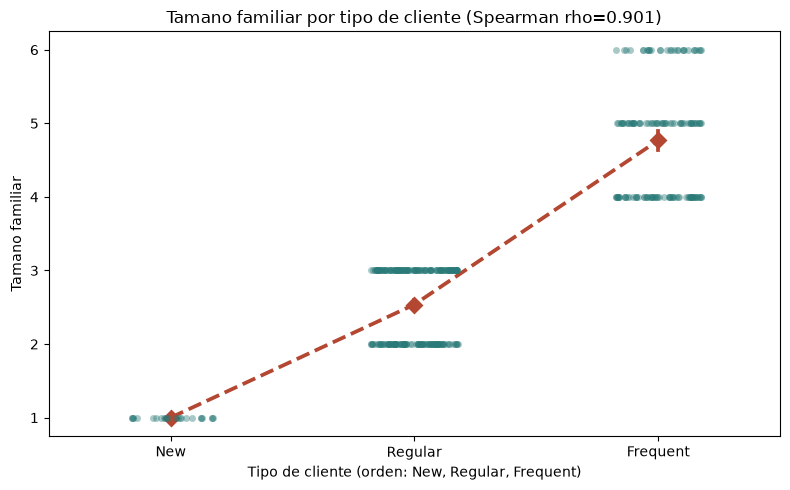

Correlacion de Spearman: rho=0.901 | p-valor=4.10291e-142
La asociacion no implica causalidad.


In [7]:
import seaborn as sns
from scipy.stats import spearmanr

orden_cliente = ["New", "Regular", "Frequent"]
rango_cliente = {categoria: rango for rango, categoria in enumerate(orden_cliente)}
cliente_ordenado = df["Customer Type"].map(rango_cliente)
assert cliente_ordenado.notna().all(), "Hay categorias de cliente sin ordenar."
rho_spearman, p_spearman = spearmanr(cliente_ordenado, df["Family size"])

resumen_tipos = pd.DataFrame(
    [
        {
            "variable": "Customer Type",
            "tipo_analitico": "Categórica ordinal",
            "dtype_pandas": str(df["Customer Type"].dtype),
            "categorias_observadas": sorted(df["Customer Type"].dropna().unique().tolist()),
        },
        {
            "variable": "Family size",
            "tipo_analitico": "Cuantitativa discreta (conteo)",
            "dtype_pandas": str(df["Family size"].dtype),
            "categorias_observadas": sorted(df["Family size"].dropna().unique().tolist()),
        },
    ]
)
display(resumen_tipos)

fig, ax = plt.subplots(figsize=(8, 5))
sns.stripplot(
    data=df,
    x="Customer Type",
    y="Family size",
    order=orden_cliente,
    jitter=0.18,
    alpha=0.4,
    color="#297A78",
    ax=ax,
)
sns.pointplot(
    data=df,
    x="Customer Type",
    y="Family size",
    order=orden_cliente,
    errorbar=("ci", 95),
    color="#B44731",
    markers="D",
    linestyles="--",
    ax=ax,
)
ax.set_title(f"Tamano familiar por tipo de cliente (Spearman rho={rho_spearman:.3f})")
ax.set_xlabel("Tipo de cliente (orden: New, Regular, Frequent)")
ax.set_ylabel("Tamano familiar")
plt.tight_layout()
plt.show()
print(f"Correlacion de Spearman: rho={rho_spearman:.3f} | p-valor={p_spearman:.6g}")
print("La asociacion no implica causalidad.")